# Backtester V2.2.1 configurable SOLO LONG — sin información futura

Esta versión corrige el *look-ahead bias* del algoritmo original RSI + Bollinger. Todas las decisiones utilizan únicamente información que ya estaba disponible en el instante de la operación, como ocurriría en una ejecución en tiempo real.

## Secuencia temporal de entrada

1. Al cierre de una sesión se detecta sobreventa: `RSI < 35` y cierre bajo la banda inferior de Bollinger.
2. Al cierre de la sesión siguiente se confirma el rebote si su cierre supera al anterior.
3. La compra se ejecuta en la apertura de la sesión posterior a la confirmación.

## Salidas

- El stop loss del 5 % y el trailing stop del 6 % funcionan como órdenes stop durante la sesión.
- Las señales `RSI >= 65` y banda superior se calculan al cierre y se venden en la apertura siguiente.
- Una posición todavía abierta se liquida al cierre de la última sesión de la ventana.

## Uso

1. En **CONFIGURACIÓN**, active los valores y asigne sus capitales.
2. Seleccione las ventanas en `VENTANAS_MESES`.
3. Use `FECHA_FIN_VENTANA = None` o `'HOY'`, o escriba una fecha como `'2026-01-01'`.
4. Ejecute todas las celdas.

Si la fecha final no es una sesión bursátil, se utiliza la última sesión común anterior. El modelo no incluye comisiones, deslizamiento, impuestos ni remuneración del efectivo.

In [ ]:
# =================== CONFIGURACIÓN V2.2.1 SOLO LONG ===================
# Esta sección reúne los parámetros que puede modificar el usuario.

# Cada elemento contiene el ticker de Yahoo Finance y su capital asignado.
# Para activar o desactivar un valor, quite o añada # al inicio de su línea.
ACTIVOS = [
    ('META',    5_000),
    ('SHOP',    5_000),
    # ('ITX.MC',  5_000),      # España
    # ('7203.T',  5_000),      # Toyota, Japón
    # ('7974.T',  5_000),      # Nintendo, Japón
    # ('BMW.DE',  5_000),      # Alemania
    # ('MC.PA',   5_000),      # LVMH, Francia
    # ('ASML.AS', 5_000),      # Países Bajos
    # ('AAPL',    5_000),
    # ('NVDA',    5_000),
    # ('MSFT',    5_000),
    # ('AMZN',    5_000),
]

# Duraciones que se analizarán simultáneamente, expresadas en meses.
VENTANAS_MESES = [
    6,
    9,12
]
# Ejemplo alternativo:
# VENTANAS_MESES = [3, 6, 9, 12, 15, 18]

# Fecha desde la que se cuentan hacia atrás todas las ventanas.
# Opciones: None, 'HOY' o una fecha con formato 'AAAA-MM-DD'.
FECHA_FIN_VENTANA = None
# FECHA_FIN_VENTANA = '2025-05-05'

# Parámetros originales del algoritmo de la celda seleccionada.
AJUSTAR_DIVIDENDOS = True
PERIODO_RSI = 14
PERIODO_BOLLINGER = 20
DESVIACIONES_BOLLINGER = 2
RSI_ENTRADA = 35
RSI_SALIDA = 65
STOP_LOSS_LONG = 0.05
TRAILING_STOP_LONG = 0.06
# ========================================================================

In [10]:
# ==================== IMPORTACIÓN Y PREPARACIÓN DE DATOS ====================
# Librerías estándar: avisos, carpeta temporal y manejo de rutas.
import warnings
import tempfile
from pathlib import Path

# relativedelta resta meses naturales (no un número aproximado de días).
from dateutil.relativedelta import relativedelta

# Librerías de cálculo, tablas, gráficos y descarga de cotizaciones.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
import yfinance as yf
from IPython import get_ipython
from IPython.display import display

# Se ocultan avisos no críticos para que la salida del cuaderno sea legible.
warnings.filterwarnings('ignore')

# yfinance guarda su caché de zonas horarias en la carpeta temporal del sistema.
yf.set_tz_cache_location(str(Path(tempfile.gettempdir()) / 'yf_backtester_v22_config_cache'))

# Activa los gráficos integrados solo cuando el código se ejecuta en Jupyter.
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

# ---------------------- Validación de la configuración ----------------------
# Estas comprobaciones detienen pronto el programa y muestran un mensaje claro
# si el usuario ha escrito una configuración imposible o ambigua.
if not 1 <= len(ACTIVOS) <= 12:
    raise ValueError('Debes activar entre 1 y 12 valores.')

# Se normalizan los tickers a mayúsculas y se crea un diccionario ticker-capital.
tickers = [str(t).strip().upper() for t, _ in ACTIVOS]
capitales = {str(t).strip().upper(): float(c) for t, c in ACTIVOS}
if len(set(tickers)) != len(tickers):
    raise ValueError('No puede haber tickers duplicados en ACTIVOS.')
if any(c <= 0 for c in capitales.values()):
    raise ValueError('Todos los capitales deben ser mayores que cero.')
if not VENTANAS_MESES or any(not isinstance(m, int) or m <= 0 for m in VENTANAS_MESES):
    raise ValueError('VENTANAS_MESES debe contener enteros positivos.')

# Se eliminan ventanas repetidas y se ordenan de menor a mayor.
VENTANAS_MESES = sorted(set(VENTANAS_MESES))

# ---------------------- Resolución de la fecha final V2.2 -------------------
# None y el texto HOY significan lo mismo: la fecha actual, sin hora.
if FECHA_FIN_VENTANA is None or str(FECHA_FIN_VENTANA).strip().upper() == 'HOY':
    fecha_fin_solicitada = pd.Timestamp.today().normalize()
else:
    try:
        fecha_fin_solicitada = pd.Timestamp(FECHA_FIN_VENTANA).normalize()
    except (TypeError, ValueError) as exc:
        raise ValueError(
            "FECHA_FIN_VENTANA debe ser None, 'HOY' o una fecha válida 'AAAA-MM-DD'."
        ) from exc

# No se admiten fechas futuras porque todavía no existen cotizaciones para ellas.
hoy = pd.Timestamp.today().normalize()
if fecha_fin_solicitada > hoy:
    raise ValueError('FECHA_FIN_VENTANA no puede ser posterior a la fecha actual.')

# Se descargan cinco meses extra antes de la ventana mayor. Ese margen permite
# calcular RSI y Bollinger sin perder el inicio efectivo del backtest.
max_meses = max(VENTANAS_MESES)
inicio_descarga = fecha_fin_solicitada - relativedelta(months=max_meses + 5)

datos_raw = {}
errores = []

# BUCLE DE DESCARGA: recorre una vez cada ticker activo, descarga sus velas
# diarias, homogeneiza columnas/fechas y guarda el DataFrame ya limpio.
for ticker in tickers:
    try:
        # yfinance interpreta end como límite exclusivo; se suma un día para
        # incluir FECHA_FIN_VENTANA cuando esta sea una sesión bursátil.
        d = yf.download(
            ticker,
            start=inicio_descarga,
            end=fecha_fin_solicitada + pd.Timedelta(days=1),
            interval='1d',
            auto_adjust=AJUSTAR_DIVIDENDOS,
            progress=False,
            threads=False
        )

        # Algunas versiones de yfinance devuelven columnas multinivel incluso
        # al pedir un único ticker. Aquí se convierten en columnas sencillas.
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = d.columns.get_level_values(0)

        # Solo se conservan los campos OHLCV que utiliza la estrategia.
        d = d[['Open', 'High', 'Low', 'Close', 'Volume']].dropna().copy()

        # Se eliminan zona horaria y hora para comparar únicamente fechas.
        if getattr(d.index, 'tz', None) is not None:
            d.index = d.index.tz_localize(None)
        d.index = pd.to_datetime(d.index).normalize()
        d = d[~d.index.duplicated(keep='last')].sort_index()

        # Sesenta sesiones son el mínimo prudente para indicadores y backtest.
        if len(d) < 60:
            raise ValueError(f'solo se recibieron {len(d)} sesiones')
        datos_raw[ticker] = d
    except Exception as exc:
        # No se interrumpe el bucle: se recopilan todos los fallos para informar
        # juntos al usuario al terminar de intentar las descargas.
        errores.append(f'{ticker}: {exc}')

if errores:
    raise RuntimeError('Error descargando datos:\n' + '\n'.join(errores))

# Cada mercado puede tener festivos distintos. El mínimo de sus últimas fechas
# garantiza que todos los activos terminan en una sesión realmente compartida.
ultima_fecha_comun = min(d.index.max() for d in datos_raw.values())

print('Valores activos:', ', '.join(f'{t} ({capitales[t]:,.2f})' for t in tickers))
print('Ventanas activas:', ', '.join(f'{m} meses' for m in VENTANAS_MESES))
print('Fecha final solicitada:', fecha_fin_solicitada.date())
print('Última sesión común utilizada:', ultima_fecha_comun.date())

Valores activos: META (5,000.00), SHOP (5,000.00)
Ventanas activas: 6 meses, 9 meses
Fecha final solicitada: 2025-05-05
Última sesión común utilizada: 2025-05-05


In [11]:
# ========================= CÁLCULO DE INDICADORES =========================
def preparar_senales(df):
    """Calcula los indicadores del algoritmo original RSI + Bollinger."""
    d = df.copy()

    # Bollinger: media móvil de 20 sesiones y bandas situadas a dos
    # desviaciones típicas. Se calculan tanto la banda inferior como la superior.
    d['MA20'] = d['Close'].rolling(PERIODO_BOLLINGER).mean()
    d['STD20'] = d['Close'].rolling(PERIODO_BOLLINGER).std()
    d['BB_SUP'] = d['MA20'] + DESVIACIONES_BOLLINGER * d['STD20']
    d['BB_INF'] = d['MA20'] - DESVIACIONES_BOLLINGER * d['STD20']

    # RSI original: medias aritméticas móviles de ganancias y pérdidas de las
    # últimas 14 sesiones. No se sustituye por la variante exponencial de Wilder.
    delta = d['Close'].diff()
    ganancias = delta.clip(lower=0)
    perdidas = -delta.clip(upper=0)
    media_ganancias = ganancias.rolling(PERIODO_RSI).mean()
    media_perdidas = perdidas.rolling(PERIODO_RSI).mean()
    rs = media_ganancias / media_perdidas
    d['RSI'] = 100 - (100 / (1 + rs))

    return d


# BUCLE IMPLÍCITO: prepara de forma independiente los indicadores de cada activo
# y limita todos los históricos a la última fecha común disponible.
datos = {
    ticker: preparar_senales(d.loc[d.index <= ultima_fecha_comun])
    for ticker, d in datos_raw.items()
}

In [12]:
# ============== MOTOR V2.2.1 SIN INFORMACIÓN FUTURA ==============
def ejecutar_v221_solo_long(ticker, fecha_inicio, capital_inicial):
    """Ejecuta RSI + Bollinger respetando estrictamente el orden temporal.

    Las señales confirmadas al cierre se ejecutan, como pronto, en la apertura
    de la sesión siguiente. Los stops utilizan precios ya fijados previamente.
    """
    d = datos[ticker]
    fechas = d.index[(d.index >= fecha_inicio) & (d.index <= ultima_fecha_comun)]
    df = d.loc[fechas].copy()

    # Hacen falta al menos tres filas: sobreventa, confirmación y ejecución.
    if len(df) < 3:
        raise ValueError(f'{ticker}: datos insuficientes para la ventana solicitada.')

    capital = float(capital_inicial)
    acciones = 0.0
    precio_entrada = None
    fecha_entrada = None
    max_cierre_desde_entrada = None
    operaciones = []
    equity = []

    def cerrar(fecha, precio_salida, motivo):
        """Vende todas las acciones y registra el resultado de la operación."""
        nonlocal capital, acciones, precio_entrada
        nonlocal fecha_entrada, max_cierre_desde_entrada

        capital = acciones * precio_salida
        rentabilidad_operacion = (
            precio_salida / precio_entrada - 1
        ) * 100
        operaciones.append({
            'Ticker': ticker,
            'Tipo': 'LONG',
            'Sistema entrada': 'RSI + BOLLINGER + CONFIRMACIÓN CAUSAL',
            'Entrada': fecha_entrada,
            'Precio entrada': precio_entrada,
            'Salida': fecha,
            'Precio salida': precio_salida,
            'Rentabilidad %': rentabilidad_operacion,
            'Motivo': motivo
        })
        acciones = 0.0
        precio_entrada = None
        fecha_entrada = None
        max_cierre_desde_entrada = None

    # BUCLE PRINCIPAL: i empieza en 2 porque una entrada necesita dos sesiones
    # ya terminadas: i-2 detecta la sobreventa e i-1 confirma el rebote.
    for i in range(2, len(df)):
        fecha = df.index[i]
        fila = df.iloc[i]
        ayer = df.iloc[i - 1]
        anteayer = df.iloc[i - 2]

        apertura = float(fila['Open'])
        minimo = float(fila['Low'])
        cierre = float(fila['Close'])
        estaba_dentro = acciones > 0

        # ---------------------------------------------------------
        # 1) SALIDAS CON INFORMACIÓN DISPONIBLE ANTES DE LA APERTURA
        # ---------------------------------------------------------
        if estaba_dentro:
            # Estas señales se produjeron al cierre de ayer; por eso la orden
            # puede ejecutarse legítimamente en la apertura de hoy.
            if float(ayer['RSI']) >= RSI_SALIDA:
                cerrar(fecha, apertura, f'RSI >= {RSI_SALIDA}')
            elif float(ayer['Close']) >= float(ayer['BB_SUP']):
                cerrar(fecha, apertura, 'BOLLINGER SUPERIOR')

        # ---------------------------------------------------------
        # 2) ENTRADA CAUSAL EN LA APERTURA
        # ---------------------------------------------------------
        # La sobreventa de anteayer y la confirmación de ayer son conocidas antes
        # de la apertura actual. Nunca se consulta el cierre de la sesión actual.
        if not estaba_dentro and acciones == 0:
            sobreventa_confirmada = (
                float(anteayer['RSI']) < RSI_ENTRADA
                and float(anteayer['Close']) <= float(anteayer['BB_INF'])
                and float(ayer['Close']) > float(anteayer['Close'])
            )
            if sobreventa_confirmada:
                precio_entrada = apertura
                acciones = capital / precio_entrada
                fecha_entrada = fecha
                max_cierre_desde_entrada = precio_entrada

        # ---------------------------------------------------------
        # 3) STOPS INTRADÍA PREDETERMINADOS
        # ---------------------------------------------------------
        if acciones > 0:
            stop_fijo = precio_entrada * (1 - STOP_LOSS_LONG)
            stop_trailing = max_cierre_desde_entrada * (1 - TRAILING_STOP_LONG)
            stop_activo = max(stop_fijo, stop_trailing)

            # El mínimo de hoy permite saber si una orden stop previamente
            # situada habría sido alcanzada durante esta sesión.
            if minimo <= stop_activo:
                motivo = (
                    'STOP LOSS' if stop_activo == stop_fijo
                    else 'TRAILING STOP'
                )
                cerrar(fecha, stop_activo, motivo)
            else:
                # El cierre actual solo actualiza el trailing para mañana; nunca
                # se utiliza retroactivamente como stop de la sesión ya terminada.
                max_cierre_desde_entrada = max(max_cierre_desde_entrada, cierre)

        # 4) VALORACIÓN al cierre con los datos de la sesión ya completada.
        valor = acciones * cierre if acciones > 0 else capital
        equity.append({'Fecha': fecha, 'Equity': valor})

    # Cierre técnico de cualquier posición viva al terminar la ventana.
    if acciones > 0:
        ultimo_cierre = float(df['Close'].iloc[-1])
        cerrar(df.index[-1], ultimo_cierre, 'FIN DEL PERIODO')
        equity[-1]['Equity'] = capital

    eq = pd.DataFrame(equity).set_index('Fecha')
    dd = (eq['Equity'] / eq['Equity'].cummax() - 1).min() * 100

    return {
        'Ticker': ticker,
        'Capital inicial': capital_inicial,
        'Capital final': capital,
        'Rentabilidad %': (capital / capital_inicial - 1) * 100,
        'Drawdown máximo %': dd,
        'Operaciones': operaciones,
        'Equity': eq,
        'Fecha inicio': df.index[0],
        'Fecha fin': df.index[-1]
    }

In [13]:
# ===== EJECUCIÓN MULTIACTIVO V2.2.1 SIN INFORMACIÓN FUTURA =====
resultados = {}  # Estructura anidada: resultados[meses][ticker].
filas = []       # Registros que después formarán la tabla comparativa.

# BUCLE EXTERIOR: crea una simulación independiente por cada duración elegida.
# La fecha inicial se calcula hacia atrás desde la fecha final común de V2.2.
for meses in VENTANAS_MESES:
    fecha_objetivo = ultima_fecha_comun - relativedelta(months=meses)
    resultados[meses] = {}

    # BUCLE INTERIOR: dentro de la ventana actual ejecuta todos los tickers con
    # su propio capital. Los activos no comparten dinero ni posiciones.
    for ticker in tickers:
        r = ejecutar_v221_solo_long(ticker, fecha_objetivo, capitales[ticker])
        resultados[meses][ticker] = r
        ops = pd.DataFrame(r['Operaciones'])

        # Cada diccionario será una fila de resultados para activo y ventana.
        filas.append({
            'Ventana (meses)': meses,
            'Ticker': ticker,
            'Fecha inicio': r['Fecha inicio'],
            'Fecha fin': r['Fecha fin'],
            'Capital inicial': r['Capital inicial'],
            'Capital final': r['Capital final'],
            'Beneficio': r['Capital final'] - r['Capital inicial'],
            'Rentabilidad %': r['Rentabilidad %'],
            'Drawdown máximo %': r['Drawdown máximo %'],
            'Operaciones': len(ops),
            'Acierto %': ops['Rentabilidad %'].gt(0).mean() * 100 if not ops.empty else 0
        })

    # Las curvas individuales se alinean por fecha y se suman para construir la
    # cartera. ffill conserva el último valor conocido cuando falta una sesión.
    curvas = [
        r['Equity']['Equity'].rename(ticker)
        for ticker, r in resultados[meses].items()
    ]
    total_eq = pd.concat(curvas, axis=1).sort_index().ffill().dropna().sum(axis=1)
    capital_total = sum(capitales.values())
    final_total = float(total_eq.iloc[-1])
    dd_total = (total_eq / total_eq.cummax() - 1).min() * 100

    # Se añade una fila resumen ponderada por el capital real de cada activo.
    filas.append({
        'Ventana (meses)': meses,
        'Ticker': 'TOTAL CARTERA',
        'Fecha inicio': total_eq.index.min(),
        'Fecha fin': total_eq.index.max(),
        'Capital inicial': capital_total,
        'Capital final': final_total,
        'Beneficio': final_total - capital_total,
        'Rentabilidad %': (final_total / capital_total - 1) * 100,
        'Drawdown máximo %': dd_total,
        'Operaciones': sum(len(r['Operaciones']) for r in resultados[meses].values()),
        'Acierto %': np.nan
    })
    resultados[meses]['TOTAL CARTERA'] = {
        'Equity': total_eq.to_frame('Equity'),
        'Fecha inicio': total_eq.index.min(),
        'Fecha fin': total_eq.index.max()
    }

# Conversión de registros en una tabla con índice doble: ventana y ticker.
tabla = pd.DataFrame(filas).set_index(['Ventana (meses)', 'Ticker'])
# El título muestra la fecha final elegida en FECHA_FIN_VENTANA. Cuando esa
# fecha no es bursátil, se informa también de la sesión común realmente usada.
titulo_tabla = (
    f'TABLA COMPARATIVA — FECHA FIN DE VENTANA: '
    f'{fecha_fin_solicitada.strftime("%d/%m/%Y")}'
)
if ultima_fecha_comun != fecha_fin_solicitada:
    titulo_tabla += (
        f' — ÚLTIMA SESIÓN UTILIZADA: '
        f'{ultima_fecha_comun.strftime("%d/%m/%Y")}'
    )
print(titulo_tabla)

# El formateo afecta solo a la presentación. La fila total se resalta para que
# pueda distinguirse rápidamente de los resultados de valores individuales.
display(tabla.style.format({
    'Fecha inicio': lambda x: x.strftime('%d/%m/%Y'),
    'Fecha fin': lambda x: x.strftime('%d/%m/%Y'),
    'Capital inicial': '{:,.2f}',
    'Capital final': '{:,.2f}',
    'Beneficio': '{:+,.2f}',
    'Rentabilidad %': '{:+.2f}%',
    'Drawdown máximo %': '{:+.2f}%',
    'Acierto %': lambda x: '' if pd.isna(x) else f'{x:.1f}%'
}).apply(
    lambda fila: ['font-weight:bold;background-color:#fff3cd'] * len(fila)
    if fila.name[1] == 'TOTAL CARTERA' else [''] * len(fila),
    axis=1
))

TABLA COMPARATIVA — FECHA FIN DE VENTANA: 05/05/2025


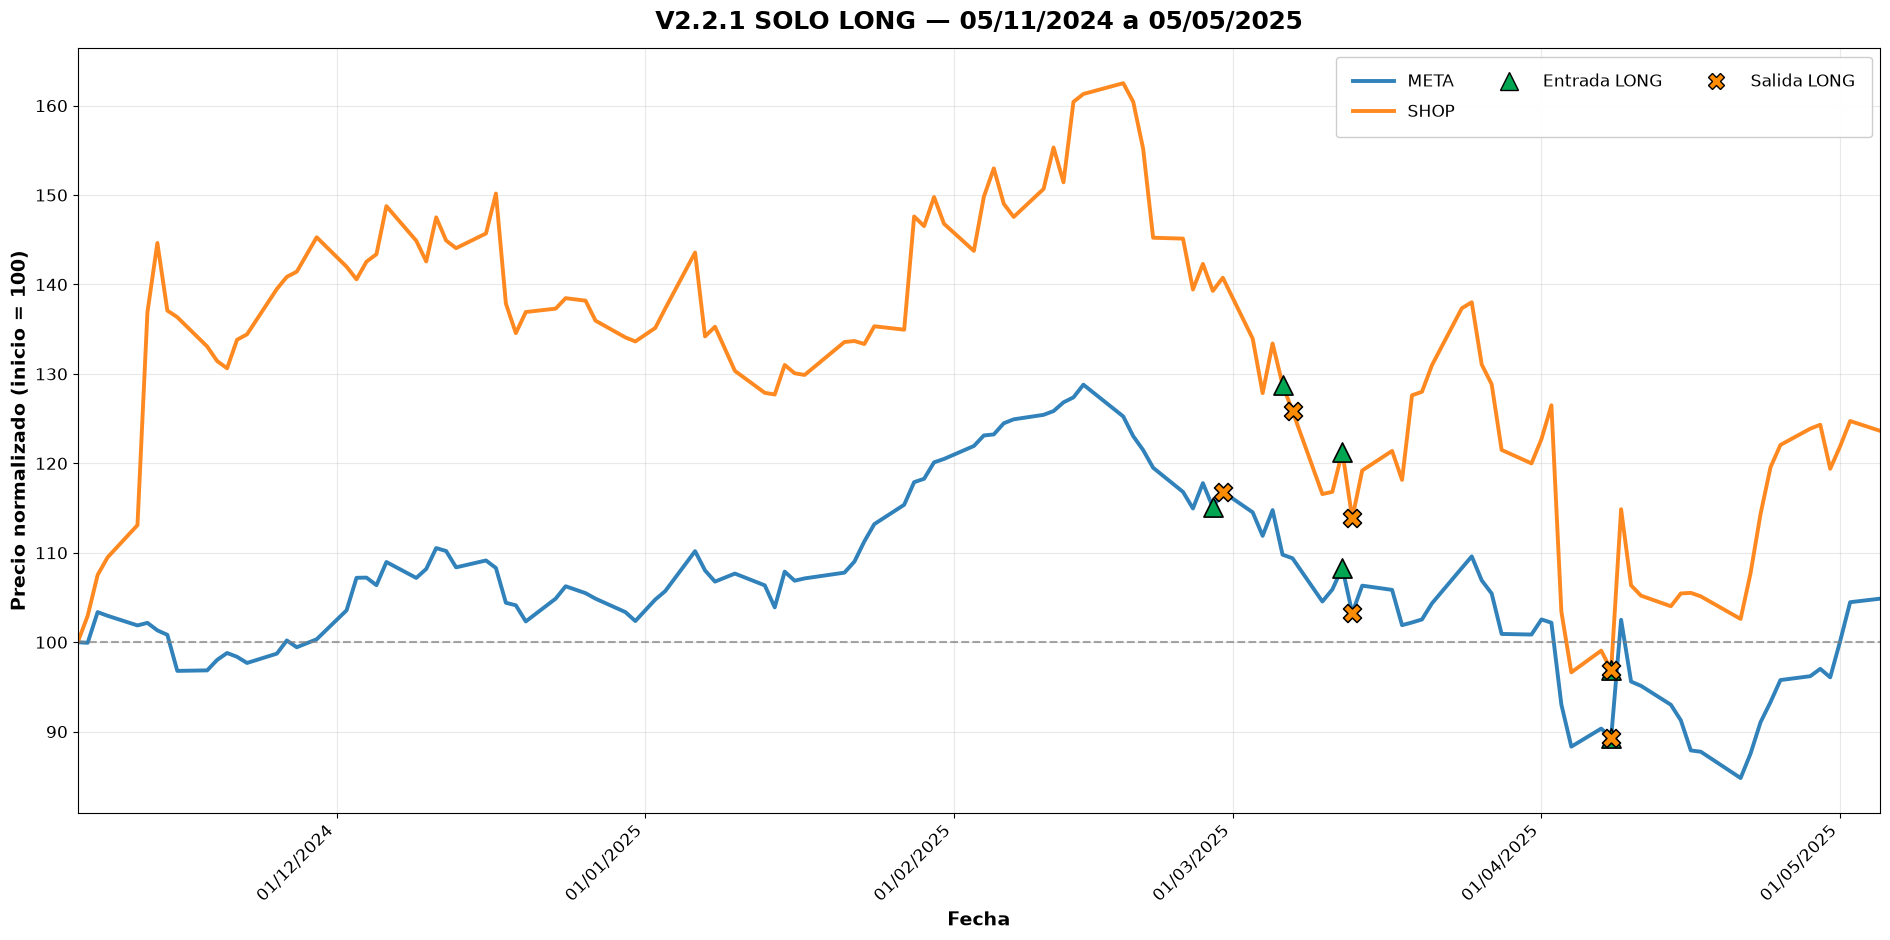

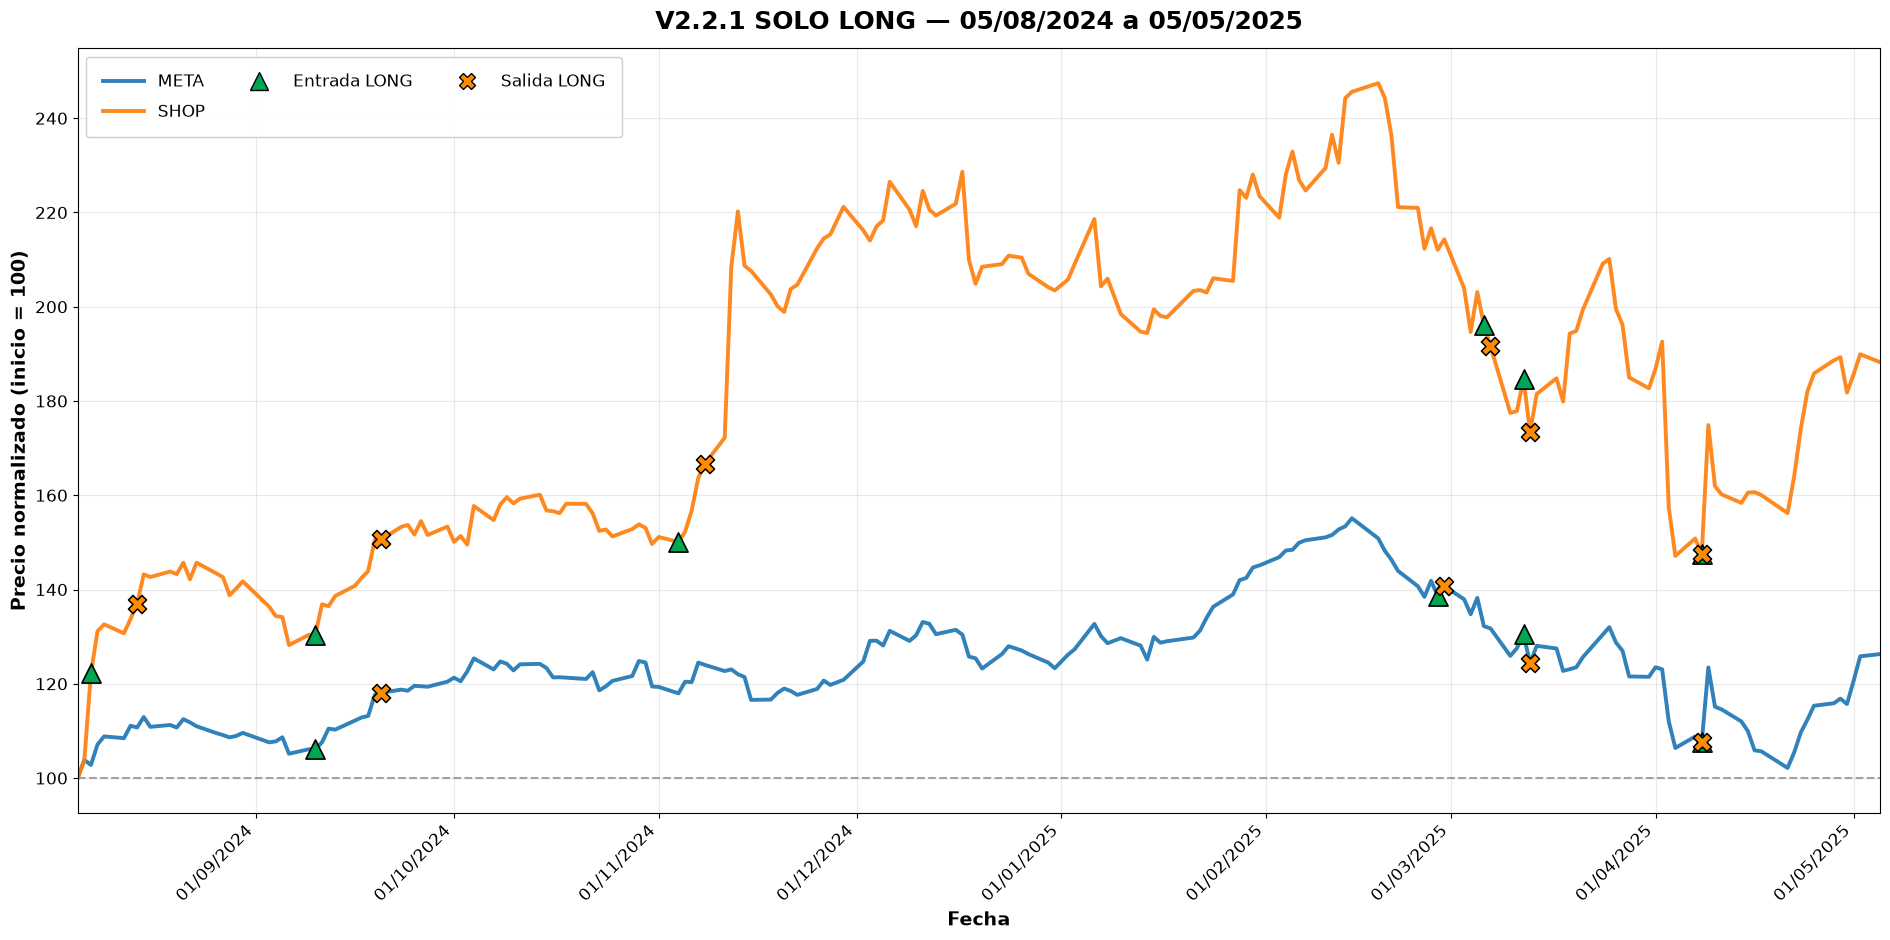

In [14]:
# ================= GRÁFICOS DE PRECIOS Y OPERACIONES LONG =================
# A cada ticker se le asigna un color estable en todos los gráficos.
paleta = plt.get_cmap('tab10')
colores = {ticker: paleta(i % 10) for i, ticker in enumerate(tickers)}

# Verde identifica una compra LONG y naranja identifica su venta de cierre.
COLOR_LONG = '#00A651'
COLOR_SALIDA = '#FF8C00'

# BUCLE DE VENTANAS: produce y guarda una figura independiente por duración.
for meses in VENTANAS_MESES:
    fig, ax = plt.subplots(figsize=(19, 9.5))
    fecha_grafico_inicio = min(resultados[meses][t]['Fecha inicio'] for t in tickers)
    fecha_grafico_fin = max(resultados[meses][t]['Fecha fin'] for t in tickers)

    # BUCLE DE ACTIVOS: dibuja cada precio normalizado y sus operaciones. La
    # normalización a 100 permite comparar activos con precios distintos.
    for ticker in tickers:
        r = resultados[meses][ticker]
        d = datos[ticker].loc[r['Fecha inicio']:r['Fecha fin']]
        normalizado = d['Close'] / d['Close'].iloc[0] * 100
        ax.plot(
            normalizado.index, normalizado, color=colores[ticker],
            lw=2.8, alpha=.92, label=ticker, zorder=2
        )

        # BUCLE DE OPERACIONES: marca con un triángulo cada compra y con una X
        # cada venta. Todas las entradas son LONG en esta variante.
        for op in r['Operaciones']:
            if op['Entrada'] in normalizado.index:
                y_entrada = float(normalizado.loc[op['Entrada']])
                ax.scatter(
                    op['Entrada'], y_entrada, color=COLOR_LONG,
                    marker='^', s=190, edgecolor='black', linewidth=1.2,
                    zorder=7
                )

            if op['Salida'] in normalizado.index:
                y_salida = float(normalizado.loc[op['Salida']])
                ax.scatter(
                    op['Salida'], y_salida, color=COLOR_SALIDA,
                    marker='X', s=170, edgecolor='black', linewidth=1.1,
                    zorder=7
                )

    # Formato común de la figura.
    ax.axhline(100, color='gray', ls='--', lw=1.5, alpha=.7)
    ax.set_title(
        f'V2.2.1 SOLO LONG — {fecha_grafico_inicio:%d/%m/%Y} a {fecha_grafico_fin:%d/%m/%Y}',
        fontsize=18, fontweight='bold', pad=14
    )
    ax.set_xlabel('Fecha', fontsize=14, fontweight='bold')
    ax.set_ylabel('Precio normalizado (inicio = 100)', fontsize=14, fontweight='bold')
    ax.set_xlim(fecha_grafico_inicio, fecha_grafico_fin)
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=12))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
    ax.grid(alpha=.28, linewidth=.8)
    ax.tick_params(axis='both', labelsize=12)

    # Leyenda: líneas automáticas de activos y dos marcadores de operaciones.
    handles, labels = ax.get_legend_handles_labels()
    handles += [
        Line2D([0], [0], marker='^', color='w', markerfacecolor=COLOR_LONG,
               markeredgecolor='black', markersize=13, label='Entrada LONG'),
        Line2D([0], [0], marker='X', color='w', markerfacecolor=COLOR_SALIDA,
               markeredgecolor='black', markersize=12, label='Salida LONG')
    ]
    ax.legend(
        handles=handles, loc='best', ncol=min(3, len(handles)),
        fontsize=12, framealpha=.96, borderpad=1.0,
        handlelength=2.5, labelspacing=.8
    )
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    nombre = f'Backtest_V2_2_1_SOLO_LONG_precios_operaciones_{meses}m.png'
    fig.savefig(nombre, dpi=170, bbox_inches='tight')
    display(fig)
    plt.close(fig)

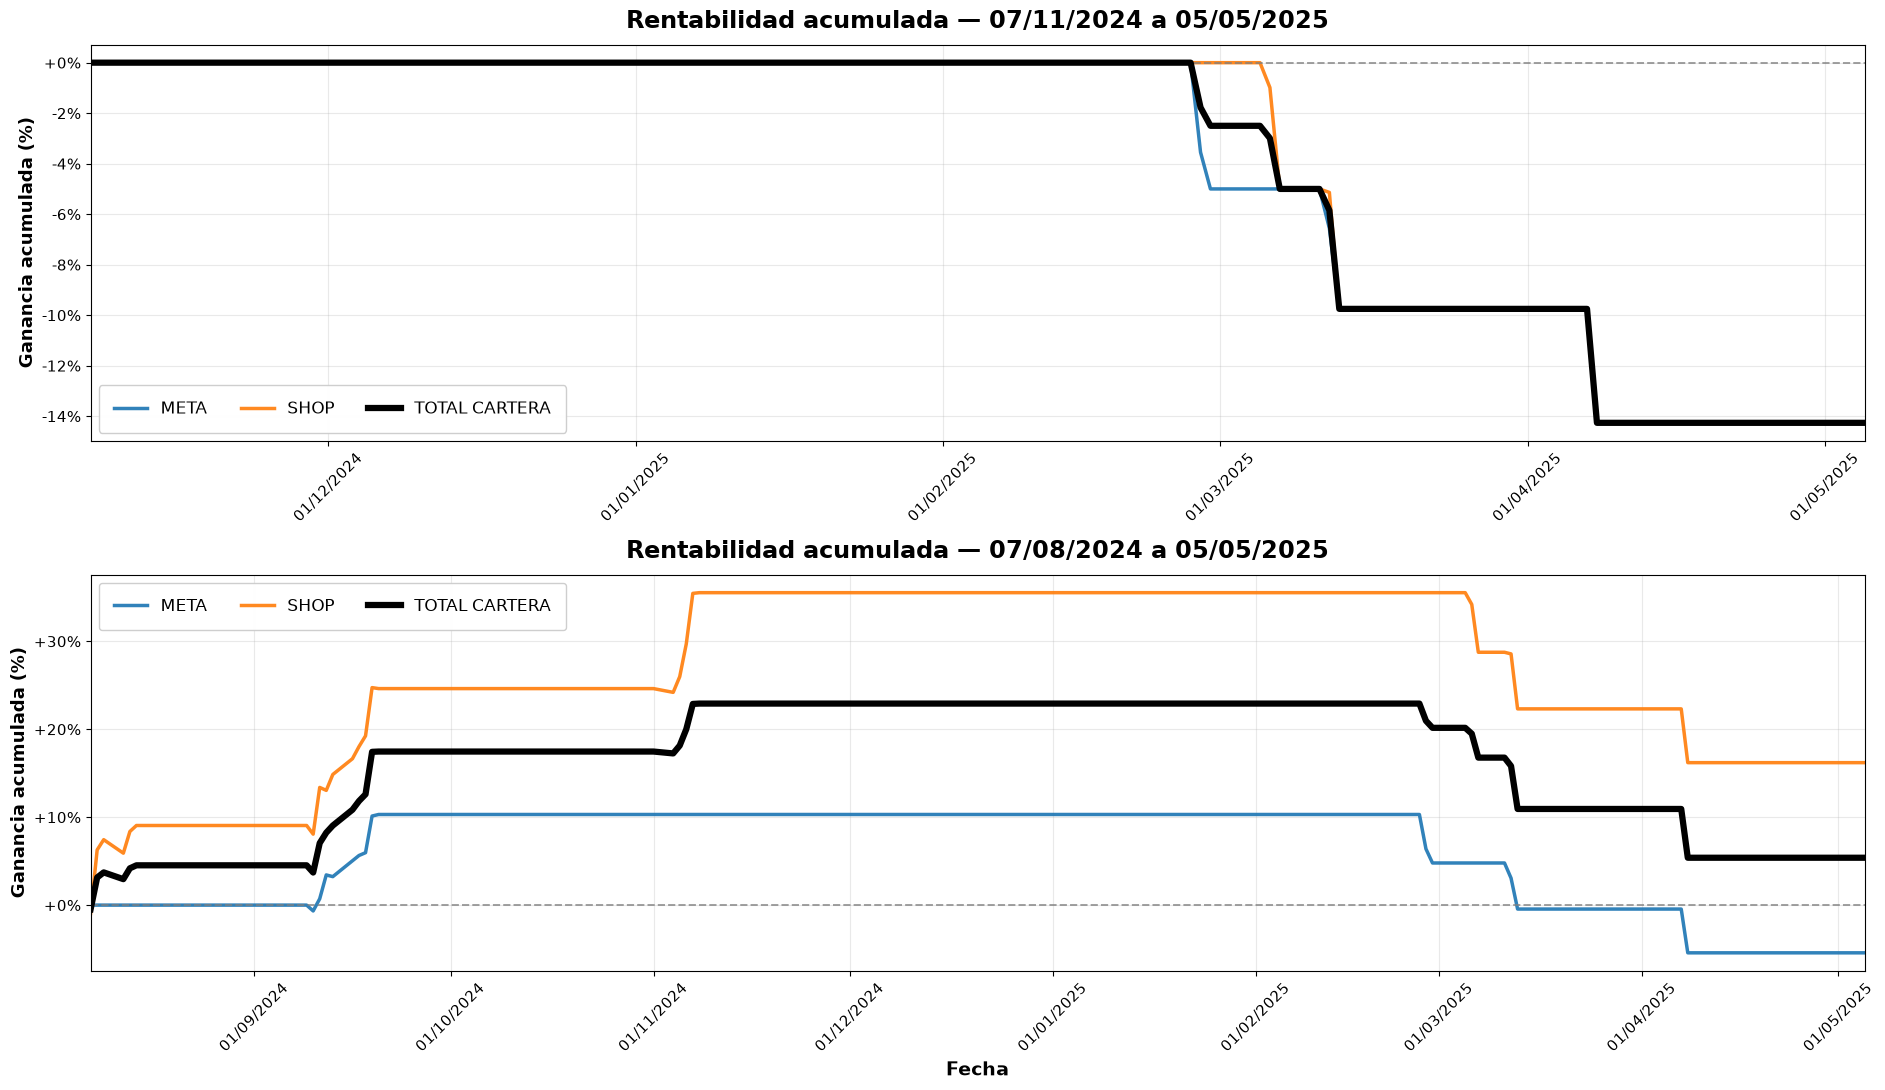

In [15]:
# ===== GRÁFICO V2.2.1 DE RENTABILIDAD SIN INFORMACIÓN FUTURA =====
# Todos los activos y la cartera total parten de 0 %, lo que permite comparar
# rentabilidades aunque los capitales iniciales asignados sean diferentes.
n = len(VENTANAS_MESES)
fig, axes = plt.subplots(n, 1, figsize=(19, max(7, 5.5 * n)), squeeze=False)

# BUCLE DE SUBGRÁFICAS: empareja cada eje con una ventana temporal activa.
for ax, meses in zip(axes[:, 0], VENTANAS_MESES):

    # BUCLE DE ACTIVOS: transforma cada curva monetaria en rentabilidad porcentual.
    for ticker in tickers:
        eq = resultados[meses][ticker]['Equity']['Equity']
        rentabilidad = (eq / capitales[ticker] - 1) * 100
        ax.plot(
            rentabilidad.index, rentabilidad, color=colores[ticker],
            lw=2.5, alpha=.92, label=ticker
        )

    # La línea negra representa el rendimiento agregado de toda la cartera.
    capital_total_inicial = sum(capitales.values())
    total = resultados[meses]['TOTAL CARTERA']['Equity']['Equity']
    rentabilidad_total = (total / capital_total_inicial - 1) * 100
    fecha_grafico_inicio = rentabilidad_total.index.min()
    fecha_grafico_fin = rentabilidad_total.index.max()
    ax.plot(
        rentabilidad_total.index, rentabilidad_total,
        color='black', lw=4.5, label='TOTAL CARTERA', zorder=6
    )

    # Formato individual de cada subgráfica.
    ax.axhline(0, color='gray', ls='--', lw=1.4, alpha=.75)
    ax.set_title(
        f'Rentabilidad acumulada — {fecha_grafico_inicio:%d/%m/%Y} a {fecha_grafico_fin:%d/%m/%Y}',
        fontsize=17, fontweight='bold', pad=12
    )
    ax.set_ylabel('Ganancia acumulada (%)', fontsize=13, fontweight='bold')
    ax.set_xlim(fecha_grafico_inicio, fecha_grafico_fin)
    ax.margins(x=0)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=12))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m/%Y'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:+.0f}%'))
    ax.grid(alpha=.28, linewidth=.8)
    ax.legend(
        loc='best', ncol=min(4, len(tickers) + 1),
        fontsize=12, framealpha=.96, borderpad=.9
    )
    ax.tick_params(axis='both', labelsize=11)
    ax.tick_params(axis='x', rotation=45)

# Etiqueta inferior compartida y exportación del resumen completo.
axes[-1, 0].set_xlabel('Fecha', fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(
    'Backtest_V2_2_1_SOLO_LONG_resumen_rentabilidad_porcentual.png',
    dpi=170, bbox_inches='tight'
)
display(fig)
plt.close(fig)

## Interpretación y límites

- Esta versión no utiliza información futura: cada señal de cierre se ejecuta en una sesión posterior.
- La compra se retrasa una sesión respecto al algoritmo original porque el cierre que confirma el rebote debe conocerse antes de enviar la orden.
- Los stops se fijan antes de la sesión. El máximo de cierre de hoy solo modifica el trailing aplicable desde la sesión siguiente.
- La estrategia nunca abre posiciones SHORT y permanece en efectivo mientras no exista una señal LONG completa.
- `FECHA_FIN_VENTANA` determina el final; si no hay cotización ese día, se usa la última sesión común anterior.
- Cada activo utiliza exclusivamente su capital configurado, sin transferencias ni rebalanceos.
- El modelo supone ejecución exacta al precio del stop. En la realidad, un hueco de apertura podría producir una salida peor.
- No se incluyen comisiones, deslizamiento, impuestos, remuneración del efectivo ni conversión de divisas.
- Los resultados históricos no garantizan rendimientos futuros.